## DLA CODE OF CONDUCT V2.0

This Code of Conduct defines the principles governing ethical, transparent, and responsible use of Large Language Models (LLMs), online resources, and peer collaboration in the Deep Learning Applications laboratories. This version of the Code of Conduct was refined via a brainstorming session with **ChatGPT Version 5.2** and subsequently adapted to reflect the specific requirements and values of the DLA laboratories. In that spirit, this Code itself models the transparency it expects from you.

***Our goal is not to restrict innovation, but to ensure integrity, accountability, and genuine learning.***

### 1. Transparency in the Use of LLMs and AI Tools

The use of LLMs and AI-assisted tools is permitted — *but it must be transparent*.

* **Explicit Disclosure:** Clearly state if and how LLMs (e.g., ChatGPT, Copilot, Claude, etc.) were used. This includes code generation, debugging, data analysis, experiment design, report writing, or conceptual clarification.
* **Description of Contribution:** Briefly describe what the tool contributed and how you modified, verified, or extended its output.
* **Acknowledgment of Limitations:** Recognize that LLM outputs may contain errors, biases, or non-optimal solutions. You are responsible for verifying correctness, appropriateness, and academic integrity.

***Using AI does not reduce your responsibility for the final result.***

### 2. Proper Attribution and Documentation

Deep learning builds on existing work — responsibly.

* **Attribution:** Properly cite all external resources, including: Code snippets, Tutorials, Documentation, Datasets, Pretrained models, Research papers, and AI-generated content.
* **Reproducibility:** Clearly document tools, libraries, model versions, hyperparameters, and experimental setups so that your work can be reproduced.
* **Clarity of Modifications:** If you adapt external code, explicitly indicate what you changed and why.

***Transparency is a sign of scientific maturity — not weakness.***

### 3. Collaboration and Individual Responsibility

Discussion is encouraged. Copying is not.

* **Collaborative Learning:** You are encouraged to discuss concepts, debugging strategies, and approaches with classmates.
* **Individual Submission:** Your submitted solution must reflect your own understanding and implementation.
* **No Direct Sharing of Solutions:** Do not share complete solutions, trained models, or reports. Do not submit another person's work — or AI-generated work — as your own without meaningful engagement and proper disclosure.

***If you cannot explain your submission, it is not your submission.***

### 4. Accountability and Academic Integrity

You are responsible for everything you submit. Failure to comply with these guidelines may result in review by the course examination commission and can lead to disciplinary measures in accordance with university regulations.

***Integrity is part of your training as a machine learning practitioner.***

### 5. The Spirit of This Code of Conduct

This course prepares you to work in a field where:

* Reproducibility matters
* Ethical considerations matter
* Transparency matters
* Responsible AI use matters

***The purpose of this Code of Conduct is not surveillance — it is professional formation.***

### TL;DR

Use AI; Don’t let AI use you; Be transparent; Cite everything; Do your own thinking.

***If you can’t explain it, you probably shouldn’t submit it.***

---
---

## Introduction

In this second laboratory we will gain some experience working with Transformer models for a variety tasks using (mostly) the Hugging Face Ecosystem. 


---
### Exercise 1: Sentiment Analysis (warm up)

In this first exercise we will start from a pre-trained BERT transformer and build up a model able to perform text sentiment analysis. Transformers are complex beasts, so we will build up our pipeline in several explorative and incremental steps.

#### Exercise 1.1: Loading the Dataset Splits
There are a many sentiment analysis datasets, but we will use one of the smallest ones available: the [Cornell Rotten Tomatoes movie review dataset](https://huggingface.co/datasets/cornell-movie-review-data/rotten_tomatoes), which consists of 5,331 positive and 5,331 negative processed sentences from the Rotten Tomatoes movie reviews.

**Your first task**: Load the dataset and figure out what splits are available and how to get them. Spend some time exploring the dataset to see how it is organized. Note that we will be using the [HuggingFace Datasets](https://huggingface.co/docs/datasets/en/index) library for downloading, accessing, splitting, and batching data for training and evaluation.

In [1]:
# Dataset imports.
from datasets import load_dataset, get_dataset_split_names

# Your code here.

splits = get_dataset_split_names('cornell-movie-review-data/rotten_tomatoes')

print(splits)

['train', 'validation', 'test']


In [2]:
ds_dict = {split: load_dataset('cornell-movie-review-data/rotten_tomatoes', split=split) for split in splits}

In [3]:
print(ds_dict)

{'train': Dataset({
    features: ['text', 'label'],
    num_rows: 8530
}), 'validation': Dataset({
    features: ['text', 'label'],
    num_rows: 1066
}), 'test': Dataset({
    features: ['text', 'label'],
    num_rows: 1066
})}


# Let's see some random reviews

In [4]:
ds_train = ds_dict['train']
print(ds_train[0])

{'text': 'the rock is destined to be the 21st century\'s new " conan " and that he\'s going to make a splash even greater than arnold schwarzenegger , jean-claud van damme or steven segal .', 'label': 1}


In [5]:
import numpy as np
for i in range(10):
    row = ds_train[np.random.randint(0,len(ds_train))]
    print('Positive: ' if row['label'] else 'Negative: ',row['text'])

Negative:  too many scenarios in which the hero might have an opportunity to triumphantly sermonize , and too few that allow us to wonder for ourselves if things will turn out okay .
Positive:  one of those terrific documentaries that collect a bunch of people who are enthusiastic about something and then figures out how to make us share their enthusiasm .
Negative:  this is a film tailor-made for those who when they were in high school would choose the cliff-notes over reading a full-length classic .
Positive:  massoud's story is an epic , but also a tragedy , the record of a tenacious , humane fighter who was also the prisoner ( and ultimately the victim ) of history .
Negative:  though her fans will assuredly have their funny bones tickled , others will find their humor-seeking dollars best spent elsewhere .
Negative:  so-so entertainment .
Positive:  the writing is clever and the cast is appealing .
Negative:  there's something with potential here , but the movie decides , like lav

# Let's see if the dataset is balanced or not

In [6]:
type(ds_train)

datasets.arrow_dataset.Dataset

In [7]:
count_positive = np.sum(ds_train['label'] == 1)

print(count_positive)

0


### Do not work because datasets.arrow_dataset.Dataset work different than pandas Dataframes

In [8]:
count_positive = sum(label == 1 for label in ds_train['label'] )
print(f'Positives: {count_positive}, Negatives: {len(ds_train)-count_positive}' )

Positives: 4265, Negatives: 4265


In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df_train = pd.DataFrame(ds_train)

count_positive = np.sum(df_train['label'] == 1)
print(f'Positives: {count_positive}, Negatives: {len(df_train)-count_positive}' )

Positives: 4265, Negatives: 4265


### Perfectly balanced regarding the labels, but how sentences length is distributed?

In [10]:
df_train['length'] = df_train['text'].str.len()

<Axes: xlabel='length', ylabel='Count'>

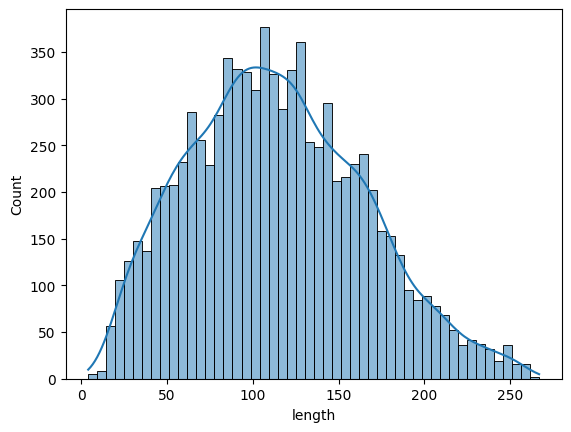

In [11]:
sns.histplot(df_train['length'], bins=50, kde=True)

### We will surely use padding but we could also think about limiting the length to avoid instances with too many [PAD] tokens

# AI use  

Asked Gemini 3.1 pro: "c'è un modo più efficiente di df_train['length'] = [len(df_train['text'][i]) for i in range(len(df_train))] per estrarre per aggiungere al dataframe pandas df_train una colonna con la lunghezza della casella 'text' per ogni series? inoltre facendo poi df_train['length'].hist() mi viene un istogramma con basi abbastanza larghe, posso customizzarlo oppure fare il plot di una curva più lineare?". From the answer i took:
- df_train['length'] = df_train['text'].str.len()
- sns.histplot(df_train['length'], bins=50, kde=True)


---
### Exercise 1.2: A Pre-trained BERT and Tokenizer

The model we will use is a *very* small BERT transformer called [DistilBERT](https://huggingface.co/distilbert/distilbert-base-uncased) this model was trained (using self-supervised learning) on the same corpus as BERT but using the full BERT base model as a *teacher*.

**Your next task**: Load the DistilBERT model and corresponding tokenizer. Use the tokenizer on a few samples from the dataset and pass the tokens through the model to see what outputs are provided. I suggest you use the [`AutoModel`](https://huggingface.co/transformers/v3.0.2/model_doc/auto.html) class (and the `from_pretrained()` method) to load the model and `AutoTokenizer` to load the tokenizer).

In [12]:
import torch
# AutoClass imports.
from transformers import AutoTokenizer, AutoModel

# Your code here.

tokenizer = AutoTokenizer.from_pretrained(
    "distilbert/distilbert-base-uncased-finetuned-sst-2-english",
)
model = AutoModel.from_pretrained(
    "distilbert/distilbert-base-uncased-finetuned-sst-2-english",
    dtype=torch.float16,
)


In [13]:
ds_train[0]['text']

'the rock is destined to be the 21st century\'s new " conan " and that he\'s going to make a splash even greater than arnold schwarzenegger , jean-claud van damme or steven segal .'

### tokenizer() and tokenizer.encode() are different!! tokenizer() is more complete and outputs also the attention mask (and token_type_ids, which DistilBert don't have). We will use tokenizer()

In [14]:
print(tokenizer(ds_train[0]['text'], return_tensors="pt"))

{'input_ids': tensor([[  101,  1996,  2600,  2003, 16036,  2000,  2022,  1996,  7398,  2301,
          1005,  1055,  2047,  1000, 16608,  1000,  1998,  2008,  2002,  1005,
          1055,  2183,  2000,  2191,  1037, 17624,  2130,  3618,  2084,  7779,
         29058,  8625, 13327,  1010,  3744,  1011, 18856, 19513,  3158,  5477,
          4168,  2030,  7112, 16562,  2140,  1012,   102]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}


In [15]:
print(tokenizer.encode(ds_train[0]['text'], return_tensors="pt"))

tensor([[  101,  1996,  2600,  2003, 16036,  2000,  2022,  1996,  7398,  2301,
          1005,  1055,  2047,  1000, 16608,  1000,  1998,  2008,  2002,  1005,
          1055,  2183,  2000,  2191,  1037, 17624,  2130,  3618,  2084,  7779,
         29058,  8625, 13327,  1010,  3744,  1011, 18856, 19513,  3158,  5477,
          4168,  2030,  7112, 16562,  2140,  1012,   102]])


In [16]:
tokens = tokenizer(ds_train[0]['text'], return_tensors="pt")
print(tokens['input_ids'])

tensor([[  101,  1996,  2600,  2003, 16036,  2000,  2022,  1996,  7398,  2301,
          1005,  1055,  2047,  1000, 16608,  1000,  1998,  2008,  2002,  1005,
          1055,  2183,  2000,  2191,  1037, 17624,  2130,  3618,  2084,  7779,
         29058,  8625, 13327,  1010,  3744,  1011, 18856, 19513,  3158,  5477,
          4168,  2030,  7112, 16562,  2140,  1012,   102]])


### If we use return_tensors="pt" while encoding the decode function give a TypeError because decode() excpects a 1D list and not a 2D tensor. The best solution is to use batch_decode(). Used Gemini 3.1 Pro: https://gemini.google.com/share/2606b4d8e371.

In [17]:
print(tokenizer.batch_decode(tokens['input_ids']))

['[CLS] the rock is destined to be the 21st century\'s new " conan " and that he\'s going to make a splash even greater than arnold schwarzenegger, jean - claud van damme or steven segal. [SEP]']


In [18]:
tokens = tokenizer(ds_train[0]['text'])
print(tokens)
print(tokenizer.decode(tokens['input_ids']))

{'input_ids': [101, 1996, 2600, 2003, 16036, 2000, 2022, 1996, 7398, 2301, 1005, 1055, 2047, 1000, 16608, 1000, 1998, 2008, 2002, 1005, 1055, 2183, 2000, 2191, 1037, 17624, 2130, 3618, 2084, 7779, 29058, 8625, 13327, 1010, 3744, 1011, 18856, 19513, 3158, 5477, 4168, 2030, 7112, 16562, 2140, 1012, 102], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}
[CLS] the rock is destined to be the 21st century's new " conan " and that he's going to make a splash even greater than arnold schwarzenegger, jean - claud van damme or steven segal. [SEP]


### Let's see how padding works. We note that for [PAD] tokens attention mask is 0

In [19]:
batch = tokenizer(ds_train[:3]['text'], return_tensors='pt', padding=True)
print(batch)

{'input_ids': tensor([[  101,  1996,  2600,  2003, 16036,  2000,  2022,  1996,  7398,  2301,
          1005,  1055,  2047,  1000, 16608,  1000,  1998,  2008,  2002,  1005,
          1055,  2183,  2000,  2191,  1037, 17624,  2130,  3618,  2084,  7779,
         29058,  8625, 13327,  1010,  3744,  1011, 18856, 19513,  3158,  5477,
          4168,  2030,  7112, 16562,  2140,  1012,   102,     0,     0,     0,
             0,     0],
        [  101,  1996,  9882,  2135,  9603, 13633,  1997,  1000,  1996,  2935,
          1997,  1996,  7635,  1000, 11544,  2003,  2061,  4121,  2008,  1037,
          5930,  1997,  2616,  3685, 23613,  6235,  2522,  1011,  3213,  1013,
          2472,  2848,  4027,  1005,  1055,  4423,  4432,  1997,  1046,  1012,
          1054,  1012,  1054,  1012, 23602,  1005,  1055,  2690,  1011,  3011,
          1012,   102],
        [  101,  4621,  2021,  2205,  1011,  8915, 23267, 16012, 24330,   102,
             0,     0,     0,     0,     0,     0,     0,     0,     

In [20]:
tokenizer.batch_decode(batch['input_ids'])

['[CLS] the rock is destined to be the 21st century\'s new " conan " and that he\'s going to make a splash even greater than arnold schwarzenegger, jean - claud van damme or steven segal. [SEP] [PAD] [PAD] [PAD] [PAD] [PAD]',
 '[CLS] the gorgeously elaborate continuation of " the lord of the rings " trilogy is so huge that a column of words cannot adequately describe co - writer / director peter jackson\'s expanded vision of j. r. r. tolkien\'s middle - earth. [SEP]',
 '[CLS] effective but too - tepid biopic [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]']

### The padding choice affects the output of the model

In [21]:
output_pad = model(**batch).last_hidden_state
output_no_pad = model(batch['input_ids']).last_hidden_state

print(output_pad - output_no_pad)

We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.


tensor([[[ 0.0547, -0.0314,  0.0159,  ...,  0.0454, -0.0527,  0.0127],
         [ 0.0337, -0.0276,  0.0038,  ..., -0.0107,  0.0054,  0.0154],
         [ 0.0327, -0.0391,  0.0137,  ..., -0.0088,  0.0015,  0.0132],
         ...,
         [ 0.5488, -0.1917,  0.3640,  ...,  0.0859,  0.3484, -0.3621],
         [ 0.6436, -0.2168, -0.2773,  ...,  0.0642,  0.4153, -0.0696],
         [ 0.5449, -0.2874, -0.3604,  ...,  0.1184,  0.3760, -0.0964]],

        [[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         ...,
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],

        [[-0.3662,  0.0798,  0.3313,  ..., -0.1460, -0.5557,  0.2450],
         [ 0.2593,  0.1865, -0.0512,  ..., -0

### Now we study the model

In [22]:
model

DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention): DistilBertSdpaAttention(
          (dropout): Dropout(p=0.1, inplace=False)
          (q_lin): Linear(in_features=768, out_features=768, bias=True)
          (k_lin): Linear(in_features=768, out_features=768, bias=True)
          (v_lin): Linear(in_features=768, out_features=768, bias=True)
          (out_lin): Linear(in_features=768, out_features=768, bias=True)
        )
        (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (ffn): FFN(
          (dropout): Dropout(p=0.1, inplace=False)
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): L

In [23]:
tokens = tokenizer(ds_train[0]['text'], return_tensors='pt')
output = model(tokens['input_ids'])
print(output)

BaseModelOutput(last_hidden_state=tensor([[[ 0.5918,  0.2058,  0.3970,  ...,  0.4331,  0.8428, -0.6680],
         [ 0.8491,  0.1558, -0.0210,  ...,  0.3418,  0.8677, -0.3516],
         [ 0.5537,  0.3970,  0.5566,  ...,  0.3142,  0.6313, -0.4067],
         ...,
         [ 0.3052,  0.1437,  0.5669,  ...,  0.2070,  0.3323, -0.5425],
         [ 1.2734,  0.1787,  0.6875,  ...,  0.5796,  0.2961, -0.9517],
         [ 1.1924,  0.2827,  0.6592,  ...,  0.6172,  0.5894, -0.8438]]],
       dtype=torch.float16, grad_fn=<NativeLayerNormBackward0>), hidden_states=None, attentions=None)


In [24]:
print(output.last_hidden_state.shape)

torch.Size([1, 47, 768])



---
### Exercise 1.3: A Stable Baseline

In this exercise I want you to:
1. Use DistilBERT as a *feature extractor* to extract representations of the text strings from the dataset splits;
2. Train a classifier (your choice, by an SVM from Scikit-learn is an easy choice).
3. Evaluate performance on the validation and test splits.

These results are our *stable baseline* -- the **starting** point on which we will (hopefully) improve in the next exercise.

**Hint**: There are a number of ways to implement the feature extractor, but probably the best is to use a [feature extraction `pipeline`](https://huggingface.co/tasks/feature-extraction). You will need to interpret the output of the pipeline and extract only the `[CLS]` token from the *last* transformer layer. *How can you figure out which output that is?*

In [25]:
from transformers import pipeline
import torch
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report

# Your code here.

tokenizer = AutoTokenizer.from_pretrained(
    "distilbert/distilbert-base-uncased-finetuned-sst-2-english",
)
model = AutoModel.from_pretrained(
    "distilbert/distilbert-base-uncased-finetuned-sst-2-english",
    dtype=torch.float16,
)

extractor = pipeline('feature-extraction', model=model, tokenizer=tokenizer)

Device set to use cuda:0


In [26]:
type(extractor(ds_train[0]['text']))

list

In [27]:
train_features = extractor(ds_train['text'], return_tensors="pt") # seems to be no difference using list(ds_train['text'])
print(type(train_features))
print(train_features)

<class 'list'>
[tensor([[[ 0.5918,  0.2054,  0.3975,  ...,  0.4333,  0.8423, -0.6685],
         [ 0.8501,  0.1555, -0.0212,  ...,  0.3418,  0.8672, -0.3518],
         [ 0.5537,  0.3972,  0.5566,  ...,  0.3142,  0.6309, -0.4065],
         ...,
         [ 0.3054,  0.1437,  0.5674,  ...,  0.2067,  0.3323, -0.5430],
         [ 1.2734,  0.1787,  0.6875,  ...,  0.5801,  0.2959, -0.9517],
         [ 1.1924,  0.2827,  0.6602,  ...,  0.6172,  0.5898, -0.8447]]],
       dtype=torch.float16), tensor([[[ 0.7285,  0.0876,  0.3538,  ...,  0.4175,  0.7354, -0.6597],
         [ 0.9648,  0.0771,  0.1741,  ...,  0.4194,  0.8188, -0.6226],
         [ 0.8374,  0.1920,  0.2484,  ...,  0.4414,  0.7344, -0.5137],
         ...,
         [-0.0247,  0.4729,  0.4490,  ...,  0.1284,  0.2629, -0.1648],
         [ 1.1816, -0.0293,  0.7026,  ...,  0.6445,  0.3135, -0.7646],
         [ 1.2002,  0.0592,  0.7393,  ...,  0.6094,  0.3948, -0.7046]]],
       dtype=torch.float16), tensor([[[-3.6816e-01,  5.2588e-01,  1.978

In [28]:
print(f'number of train features: {len(train_features)}')
print(f'shape of each feature: {train_features[0].shape}')

number of train features: 8530
shape of each feature: torch.Size([1, 47, 768])


### Since the final representation of each instance it's in the [CLS] token, we stack them all

In [29]:
cls_tokens = [feat[0][0] for feat in train_features]
print(cls_tokens[0].shape)

torch.Size([768])


In [30]:
train_features = torch.vstack(cls_tokens)
print(train_features.shape)

torch.Size([8530, 768])


Now that we know how to do it, we retrieve each [CLS] token from validation and test instances

In [31]:
ds_val = ds_dict['validation']
ds_test = ds_dict['test']

def extract_and_stack_cls_tokens(extractor, instances : list):
    features = extractor(instances, return_tensors="pt")
    features = torch.vstack([feat[0][0] for feat in features])
    return features

validation_features = extract_and_stack_cls_tokens(extractor=extractor, instances=ds_val['text'])
test_features = extract_and_stack_cls_tokens(extractor=extractor, instances=ds_test['text'])

In [32]:
print(validation_features.shape)
print(test_features.shape)

torch.Size([1066, 768])
torch.Size([1066, 768])


### Once we have our final train, validation and test features, we can train the SVM classifier

In [33]:
svm_classifier = LinearSVC()

svm_classifier.fit(train_features, ds_train['label'])

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [34]:
output_labels = svm_classifier.predict(test_features)
print(classification_report(output_labels, ds_test['label']))

              precision    recall  f1-score   support

           0       0.90      0.87      0.89       553
           1       0.86      0.90      0.88       513

    accuracy                           0.88      1066
   macro avg       0.88      0.88      0.88      1066
weighted avg       0.88      0.88      0.88      1066



Now we try to optimize the hyperparameters. We will use cross-validation on the training set. Used Gemini 3.1 Pro (https://gemini.google.com/share/aaadfb289365)

In [36]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from scipy.stats import loguniform

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', LinearSVC(dual=False, max_iter=5000))
])

param_distributions = {
    'svm__C': loguniform(1e-3, 1e2),
    
    'svm__penalty': ['l1', 'l2'],
    
    # squared_hinge is the only loss supported with dual=false and penalty l1
    'svm__loss': ['squared_hinge'] 
}


random_search_svm = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=10,           
    cv=5,                
    scoring='accuracy',  # Optimization metric
    n_jobs=-1,           
    random_state=42,     
    verbose=1            
)

random_search_svm.fit(train_features, ds_train['label'])


Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=5000))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'svm__C': <scipy.stats....x7f7bd205a030>, 'svm__loss': ['squared_hinge'], 'svm__penalty': ['l1', 'l2']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 `

In [39]:
print(f"Best hyperparameters: {random_search_svm.best_params_}")
print(f"Mean CV accuracy: {random_search_svm.best_score_:.4f}")

best_model = random_search_svm.best_estimator_
output_labels = best_model.predict(test_features)
print(classification_report(output_labels, ds_test['label']))

Best hyperparameters: {'svm__C': np.float64(0.0745934328572655), 'svm__loss': 'squared_hinge', 'svm__penalty': 'l1'}
Mean CV accuracy: 0.8951
              precision    recall  f1-score   support

           0       0.91      0.88      0.89       552
           1       0.87      0.91      0.89       514

    accuracy                           0.89      1066
   macro avg       0.89      0.89      0.89      1066
weighted avg       0.89      0.89      0.89      1066



---
---
## Exercise 2: Fine-tuning DistilBERT

In this exercise we will fine-tune the DistilBERT model to (hopefully) improve sentiment analysis performance.


---
### Exercise 2.1: Token Preprocessing

The first thing we need to do is *tokenize* our dataset splits -- we don't want to re-tokenize our inputs for every batch! Our current datasets return a dictionary with *strings*, but we want *input token ids* (i.e. the output of the tokenizer). This is easy enough to do by hand, but the Hugging Face `Dataset` class provides convenient, efficient, and *lazy* methods. See the documentation for [`Dataset.map`](https://huggingface.co/docs/datasets/v3.5.0/en/package_reference/main_classes#datasets.Dataset.map).

**Tip**: Verify that your new datasets are returning for every element: `text`, `label`, `intput_ids`, and `attention_mask`.

In [ ]:
# Your code here.


---
### Exercise 2.2: Setting up the Model to be Fine-tuned

In this exercise we need to prepare the base Distilbert model for fine-tuning for a *sequence classification task*. This means, at the very least, appending a new, randomly-initialized classification head connected to the `[CLS]` token of the last transformer layer. Luckily, HuggingFace already provides an `AutoModel` for just this type of instantiation: [`AutoModelForSequenceClassification`](https://huggingface.co/transformers/v3.0.2/model_doc/auto.html#automodelforsequenceclassification). You will want you instantiate one of these for fine-tuning.

In [ ]:
from transformers import AutoModelForSequenceClassification

# Your code here.


---
### Exercise 2.3: Fine-tuning DistilBERT

Finally. In this exercise you should use a HuggingFace [`Trainer`](https://huggingface.co/docs/transformers/main/en/trainer) to fine-tune your model on the Rotten Tomatoes training split. Setting up the trainer will involve (at least):


1. Instantiating a [`DataCollatorWithPadding`](https://huggingface.co/docs/transformers/en/main_classes/data_collator) object which is what *actually* does your batch construction (by padding all sequences to the same length).
2. Writing an *evaluation function* that will measure the classification accuracy. This function takes a single argument which is a tuple containing `(logits, labels)` which you should use to compute classification accuracy (and maybe other metrics like F1 score, precision, recall) and return a `dict` with these metrics.  
3. Instantiating a [`TrainingArguments`](https://huggingface.co/docs/transformers/v4.51.1/en/main_classes/trainer#transformers.TrainingArguments) object using some reasonable defaults.
4. Instantiating a `Trainer` object using your train and validation splits, you data collator, and function to compute performance metrics.
5. Calling `trainer.train()`, waiting, waiting some more, and then calling `trainer.evaluate()` to see how it did.

**Tip**: When prototyping this laboratory I discovered the HuggingFace [Evaluate library](https://huggingface.co/docs/evaluate/en/index) which provides evaluation metrics. However I found it to have insufferable layers of abstraction and getting actual metrics computed. I suggest just using the Scikit-learn metrics...

In [ ]:
# Your code here.


---
---
## Exercise 3: Choose your Own Adventure

As promised, you should choose **one** of the following exercises to work. Well, at *least* one. If you want to do them all, that is also OK! Or if you want to propose something else as a third exercise, reach out to me on the Discord!


---
### Exercise 3.1: Efficient Fine-tuning for Sentiment Analysis

In Exercise 2 we fine-tuned the *entire* Distilbert model on Rotten Tomatoes. This is expensive, even for a small model. Find an *efficient* way to fine-tune Distilbert on the Rotten Tomatoes dataset (or some other dataset).

**Hint**: You could check out the [HuggingFace PEFT library](https://huggingface.co/docs/peft/en/index) for some state-of-the-art approaches that should "just work". How else might you go about making fine-tuning more efficient without having to change your training pipeline from above?

**Why choose this exercise?** PEFT techniques -- especially LoRA are the methods of choice for adapting models to new tasks.

In [ ]:
# Your code here.


---
### Exercise 3.2: Fine-tuning a CLIP Model (harder)

Use a (small) CLIP model like [`openai/clip-vit-base-patch16`](https://huggingface.co/openai/clip-vit-base-patch16) and evaluate its zero-shot performance on a small image classification dataset like ImageNette or TinyImageNet. Fine-tune (using a parameter-efficient method!) the CLIP model to see how much improvement you can squeeze out of it.

**Note**: There are several ways to adapt the CLIP model; you could fine-tune the image encoder, the text encoder, or both. Or, you could experiment with prompt learning.

**Tip**: CLIP probably already works very well on ImageNet and ImageNet-like images. For extra fun, look for an image classification dataset with different image types (e.g. *sketches*).

**Why choose this exercise?** CLIP is probably the most widely used Vision-Language Model, and adapting it is a useful skill to master.

In [ ]:
# Your code here.


---
### Exercise 3.3: A Text-to-image Retrieval System (hard, but not *too* hard)

Implement a simple text-to-image retrieval system with a simple user interface --- using, for example, [gradio](https://www.gradio.app/), or [Marimo](https://marimo.io/), or [Shiny](https://shiny.posit.co/). Your application should *index* (e.g. compute visual descriptors for) a small dataset of images like [Flickr8k](https://huggingface.co/datasets/jxie/flickr8k). It should provide a user interface with which a user can enter a short text prompt (e.g. "a photo of dogs playing in the snow") and then display the top-10 matching images from the indexed dataset.

Note that there is no following code block with "Your code here" for this exercise. You will definitely want to implement this outside of a Jupyter Notebook.

**Hint**: The **CLIP** model is practically *made* for just such an application.

**Why choose this exercise?** Well, this is a course on Deep Learning *Applications*, and this is your chance to *build* one!

---
---